# Study 01 — Publication Quality Visualizations

## Has Morocco's Minimum Wage Protected Workers Against Inflation Since 2000?

### Morocco Economic Intelligence Lab (MEIL)

---

## Objective

This notebook produces publication-quality figures for reports, presentations and LinkedIn publications.

Each visualization is exported in high resolution.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = True

PROJECT_ROOT = Path.cwd().parent
DATA = PROJECT_ROOT / "data" / "processed"
OUTPUT = PROJECT_ROOT / "outputs"
FIGURES = OUTPUT / "figures"

FIGURES.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA / "smig_cpi_features.csv")
df.head()

,year,cpi,smig_monthly,SMIG_Index,CPI_Index,Inflation_Rate,Nominal_Wage_Growth,Real_Wage_Index,Real_Wage_Growth,Purchasing_Power_Gap,PPPR,Cumulative_Inflation,Cumulative_Wage_Growth
0,2000,83.649753,1826,100.000000,100.000000,NaN,NaN,100.000000,NaN,NaN,1.000000,0.000000,0.000000
1,2001,84.168216,1826,100.000000,100.619802,0.619802,0.000000,99.384016,-0.619802,-0.619802,0.993840,0.619802,0.000000
2,2002,86.521239,1826,100.000000,103.432749,2.795620,0.000000,96.681178,-2.795620,-2.795620,0.966812,3.432749,0.000000
3,2003,87.531577,1826,100.000000,104.640568,1.167734,0.000000,95.565231,-1.167734,-1.167734,0.955652,4.640568,0.000000
4,2004,88.838812,1845,101.040526,106.203316,1.493444,1.040526,95.138767,-0.452918,-0.452918,0.951388,6.203316,1.040526


## Figure 1 — Executive Dashboard

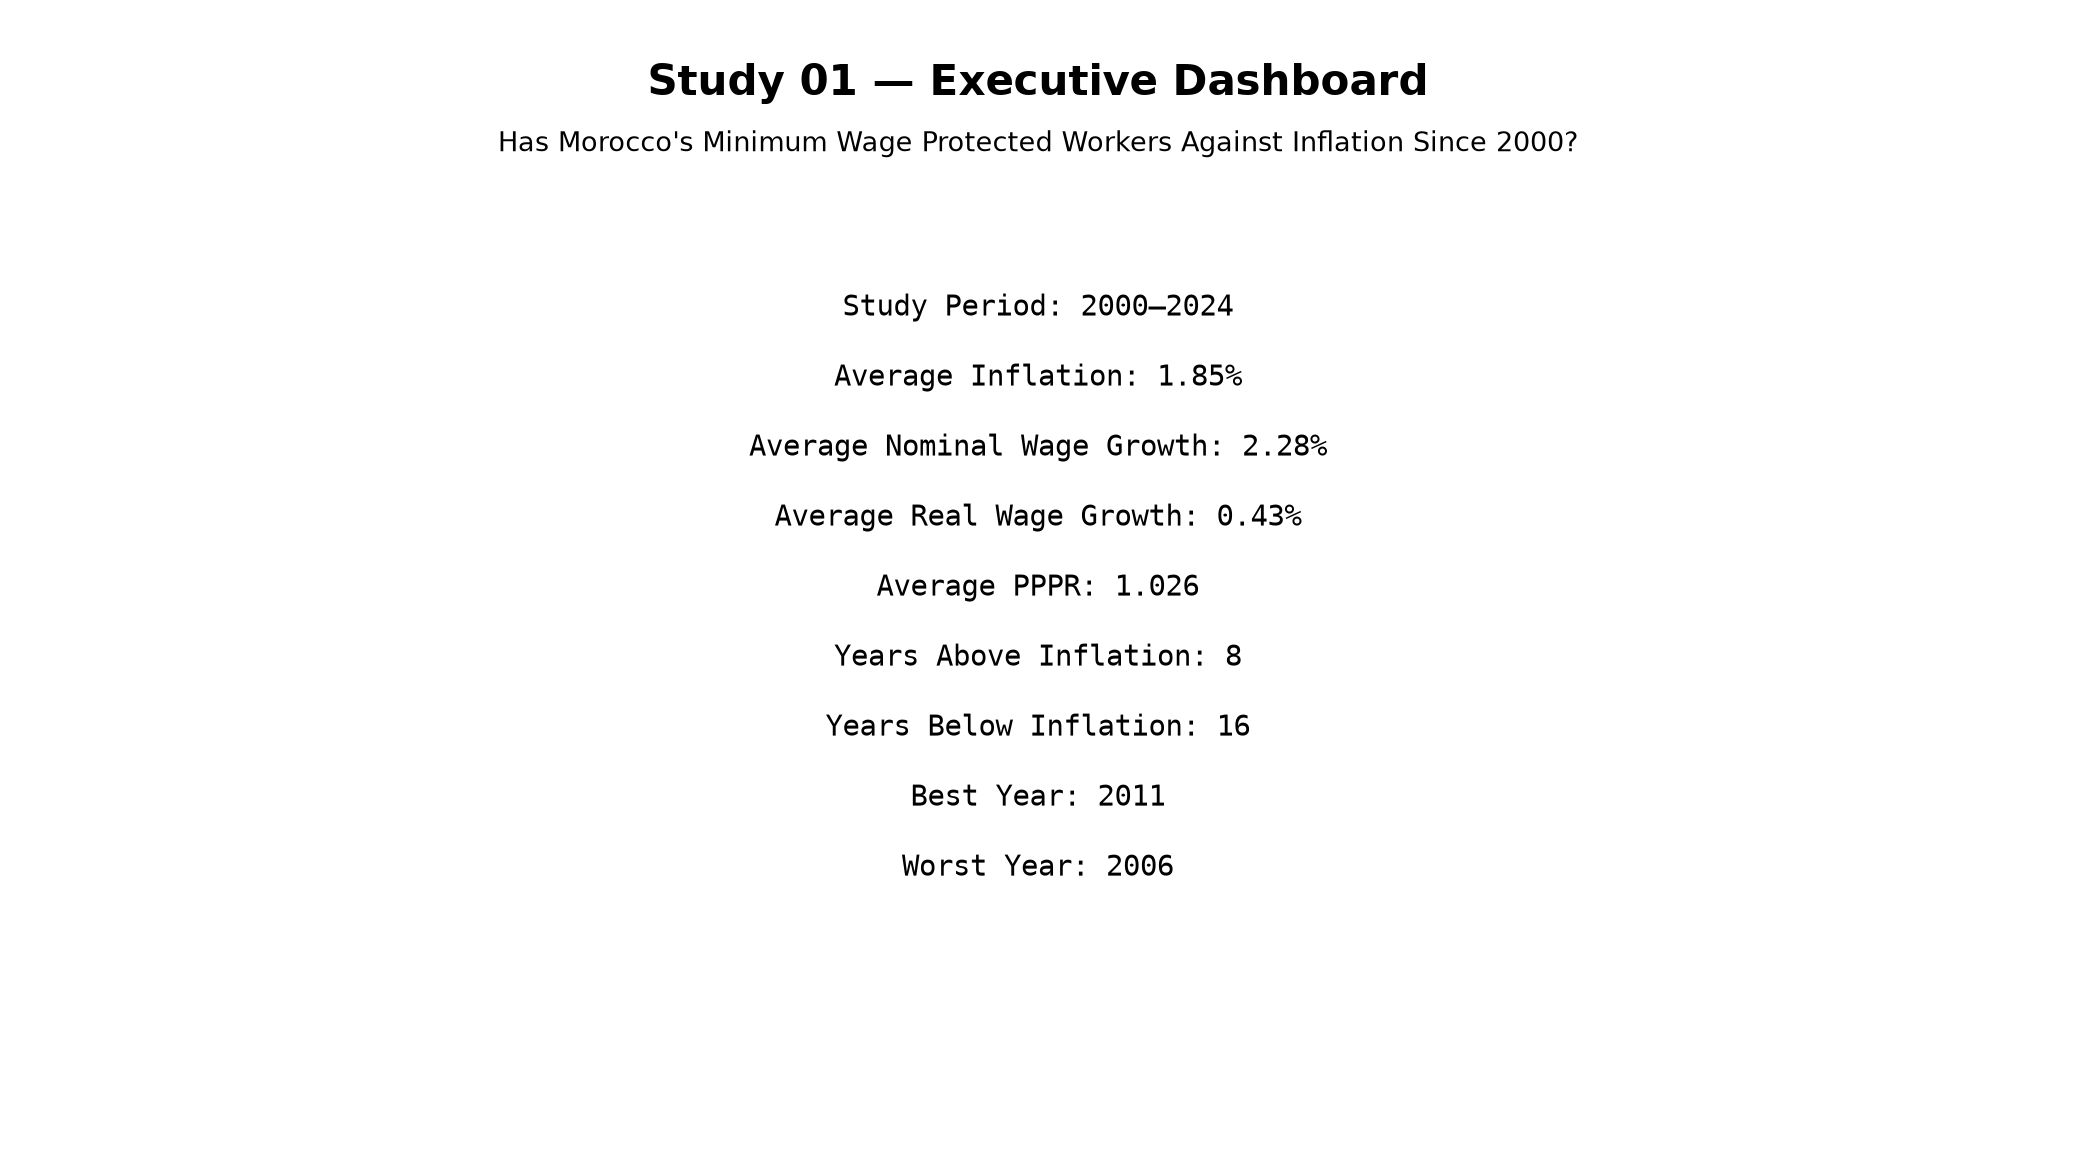

In [3]:
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")

title = "Study 01 — Executive Dashboard"
subtitle = "Has Morocco's Minimum Wage Protected Workers Against Inflation Since 2000?"

stats_text = f"""
Study Period: {df['year'].min()}–{df['year'].max()}

Average Inflation: {df['Inflation_Rate'].mean():.2f}%

Average Nominal Wage Growth: {df['Nominal_Wage_Growth'].mean():.2f}%

Average Real Wage Growth: {df['Real_Wage_Growth'].mean():.2f}%

Average PPPR: {df['PPPR'].mean():.3f}

Years Above Inflation: {(df['Purchasing_Power_Gap'] > 0).sum()}

Years Below Inflation: {(df['Purchasing_Power_Gap'] < 0).sum()}

Best Year: {int(df.loc[df['Purchasing_Power_Gap'].idxmax(), 'year'])}

Worst Year: {int(df.loc[df['Purchasing_Power_Gap'].idxmin(), 'year'])}
"""

fig.text(0.5, 0.92, title, ha="center", va="center", fontsize=20, fontweight="bold")
fig.text(0.5, 0.87, subtitle, ha="center", va="center", fontsize=13)
fig.text(0.5, 0.50, stats_text, ha="center", va="center", fontsize=14, family="monospace")

plt.tight_layout()
plt.savefig(FIGURES / "figure_01_executive_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 2 — Base 100 Comparison

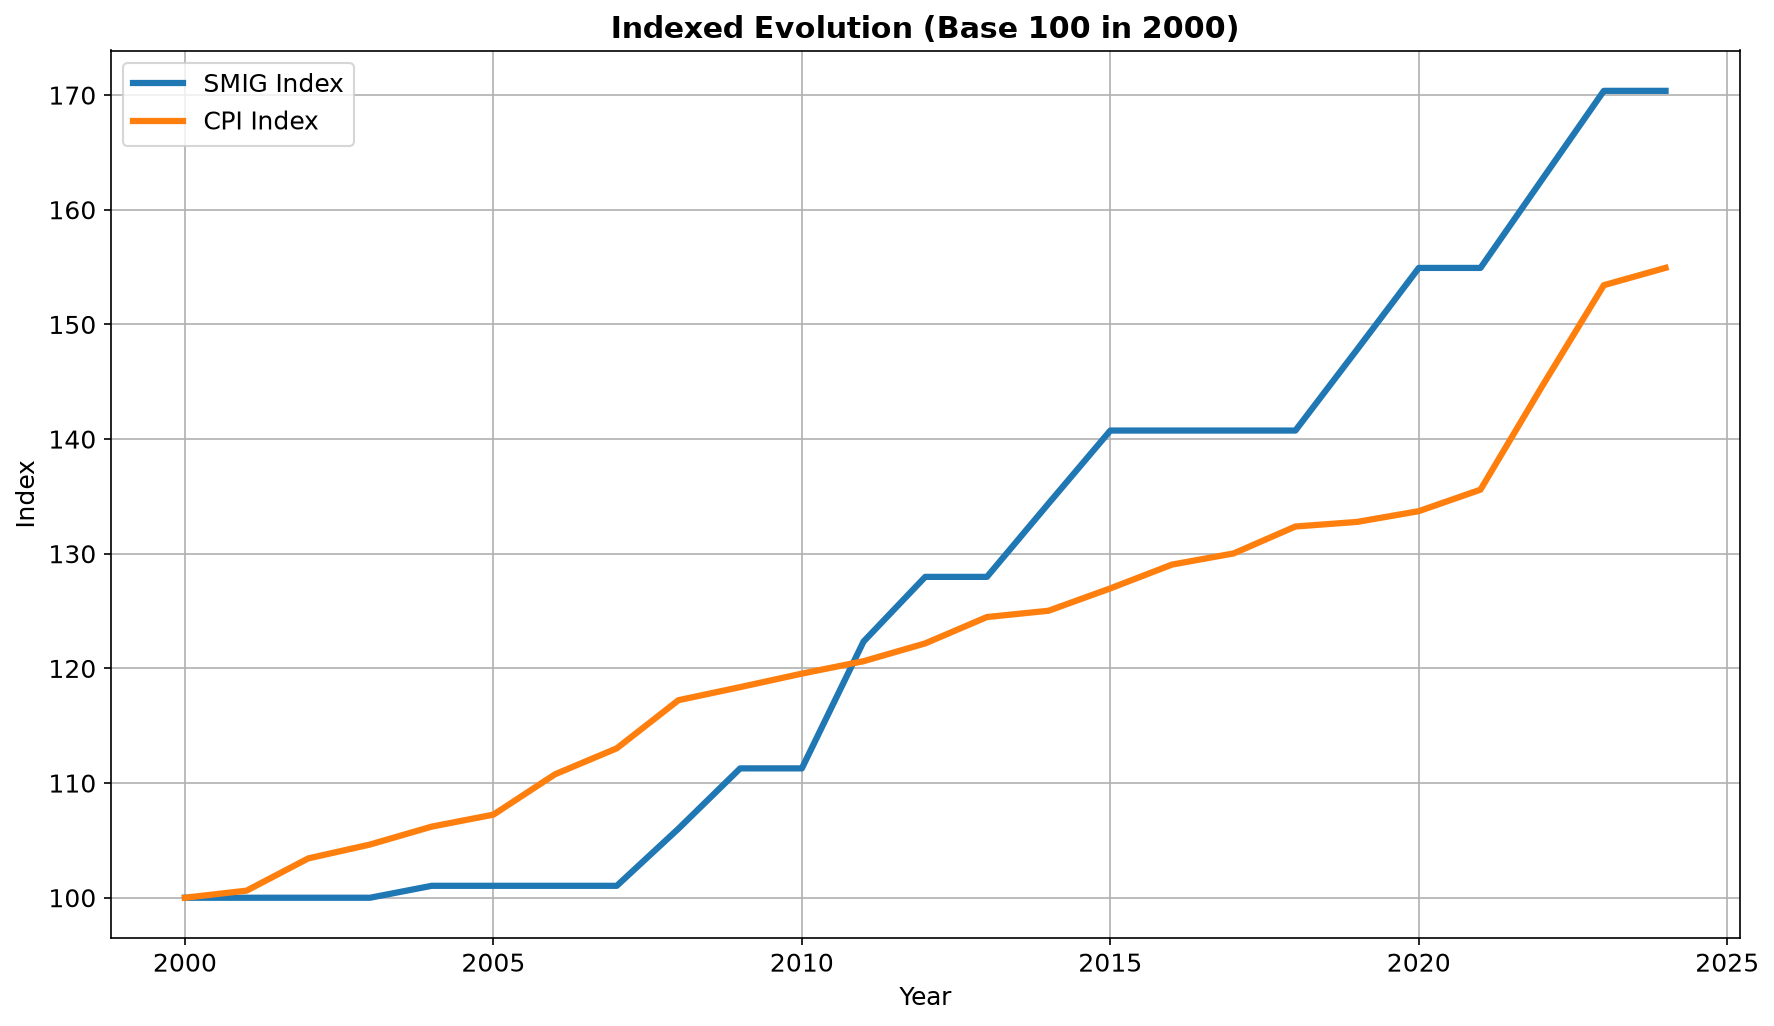

In [4]:
plt.figure()

plt.plot(
    df["year"],
    df["SMIG_Index"],
    linewidth=3,
    label="SMIG Index"
)

plt.plot(
    df["year"],
    df["CPI_Index"],
    linewidth=3,
    label="CPI Index"
)

plt.title("Indexed Evolution (Base 100 in 2000)")
plt.xlabel("Year")
plt.ylabel("Index")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES / "figure_02_base100_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Figure 3 — Purchasing Power Gap

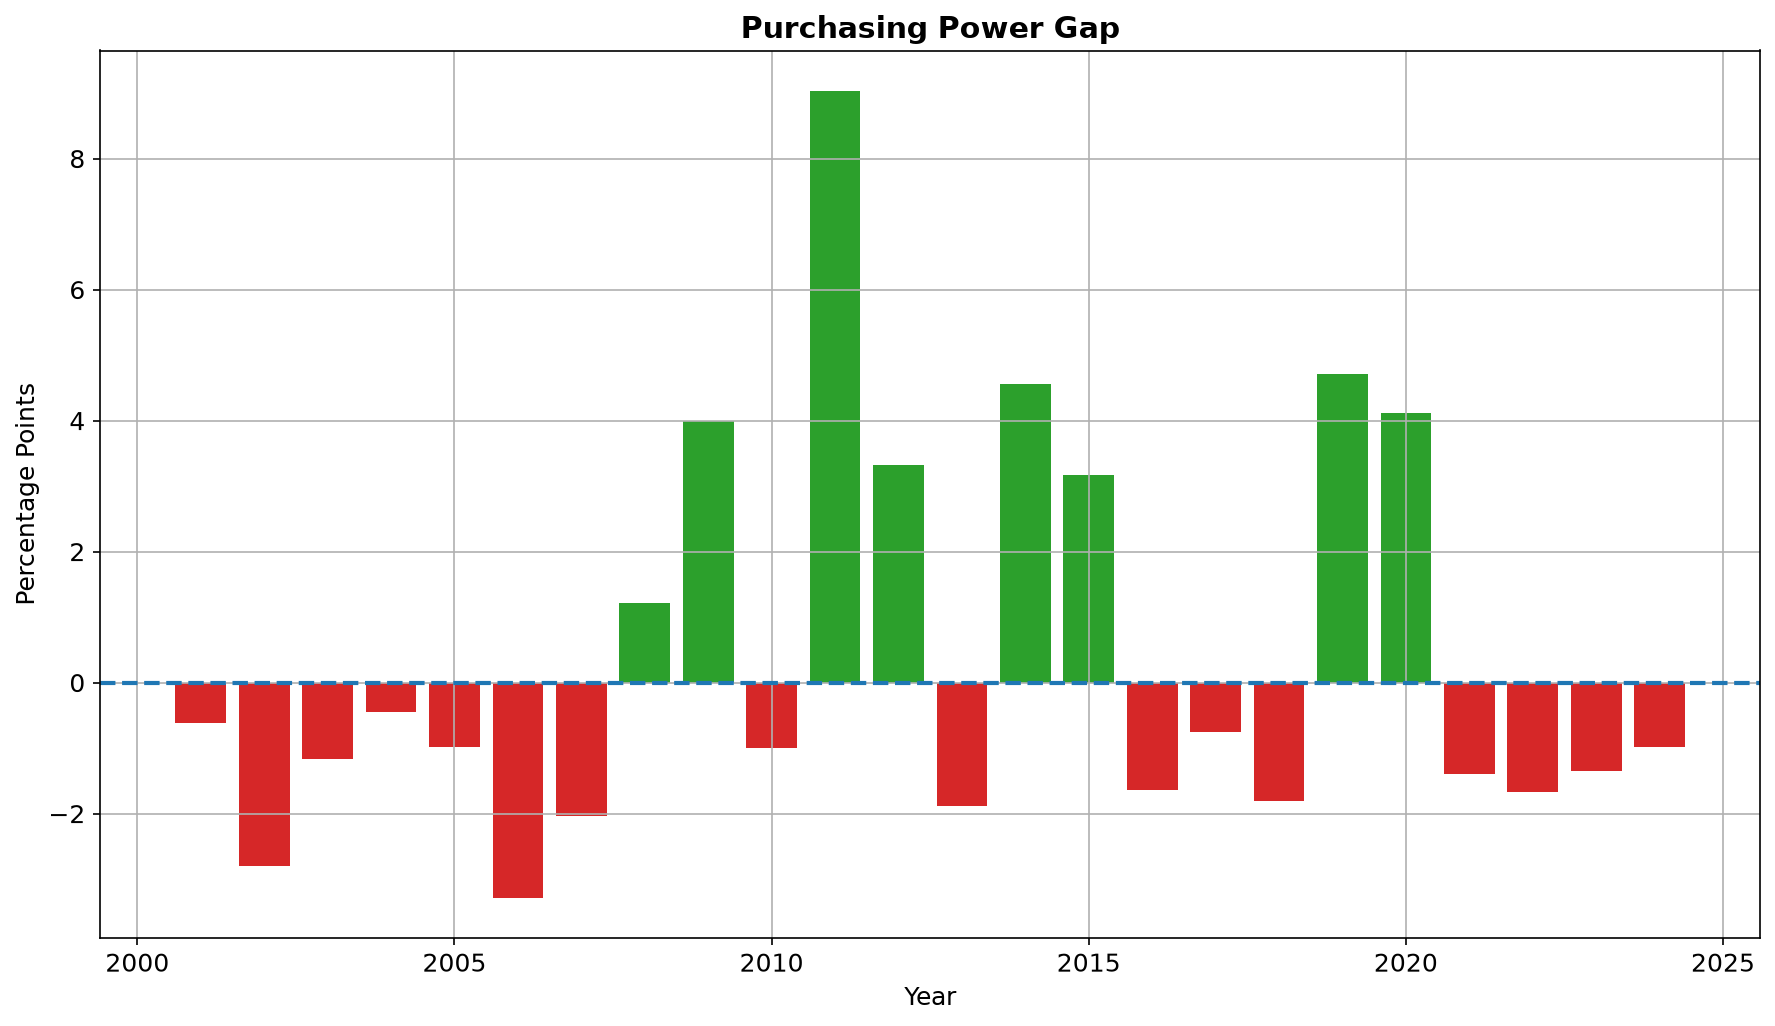

In [5]:
colors = ["#2ca02c" if x >= 0 else "#d62728" for x in df["Purchasing_Power_Gap"]]

plt.figure()

plt.bar(
    df["year"],
    df["Purchasing_Power_Gap"],
    color=colors
)

plt.axhline(y=0, linestyle="--", linewidth=2)

plt.title("Purchasing Power Gap")
plt.xlabel("Year")
plt.ylabel("Percentage Points")

plt.tight_layout()

plt.savefig(
    FIGURES / "figure_03_purchasing_power_gap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Figure 4 — Purchasing Power Protection Ratio

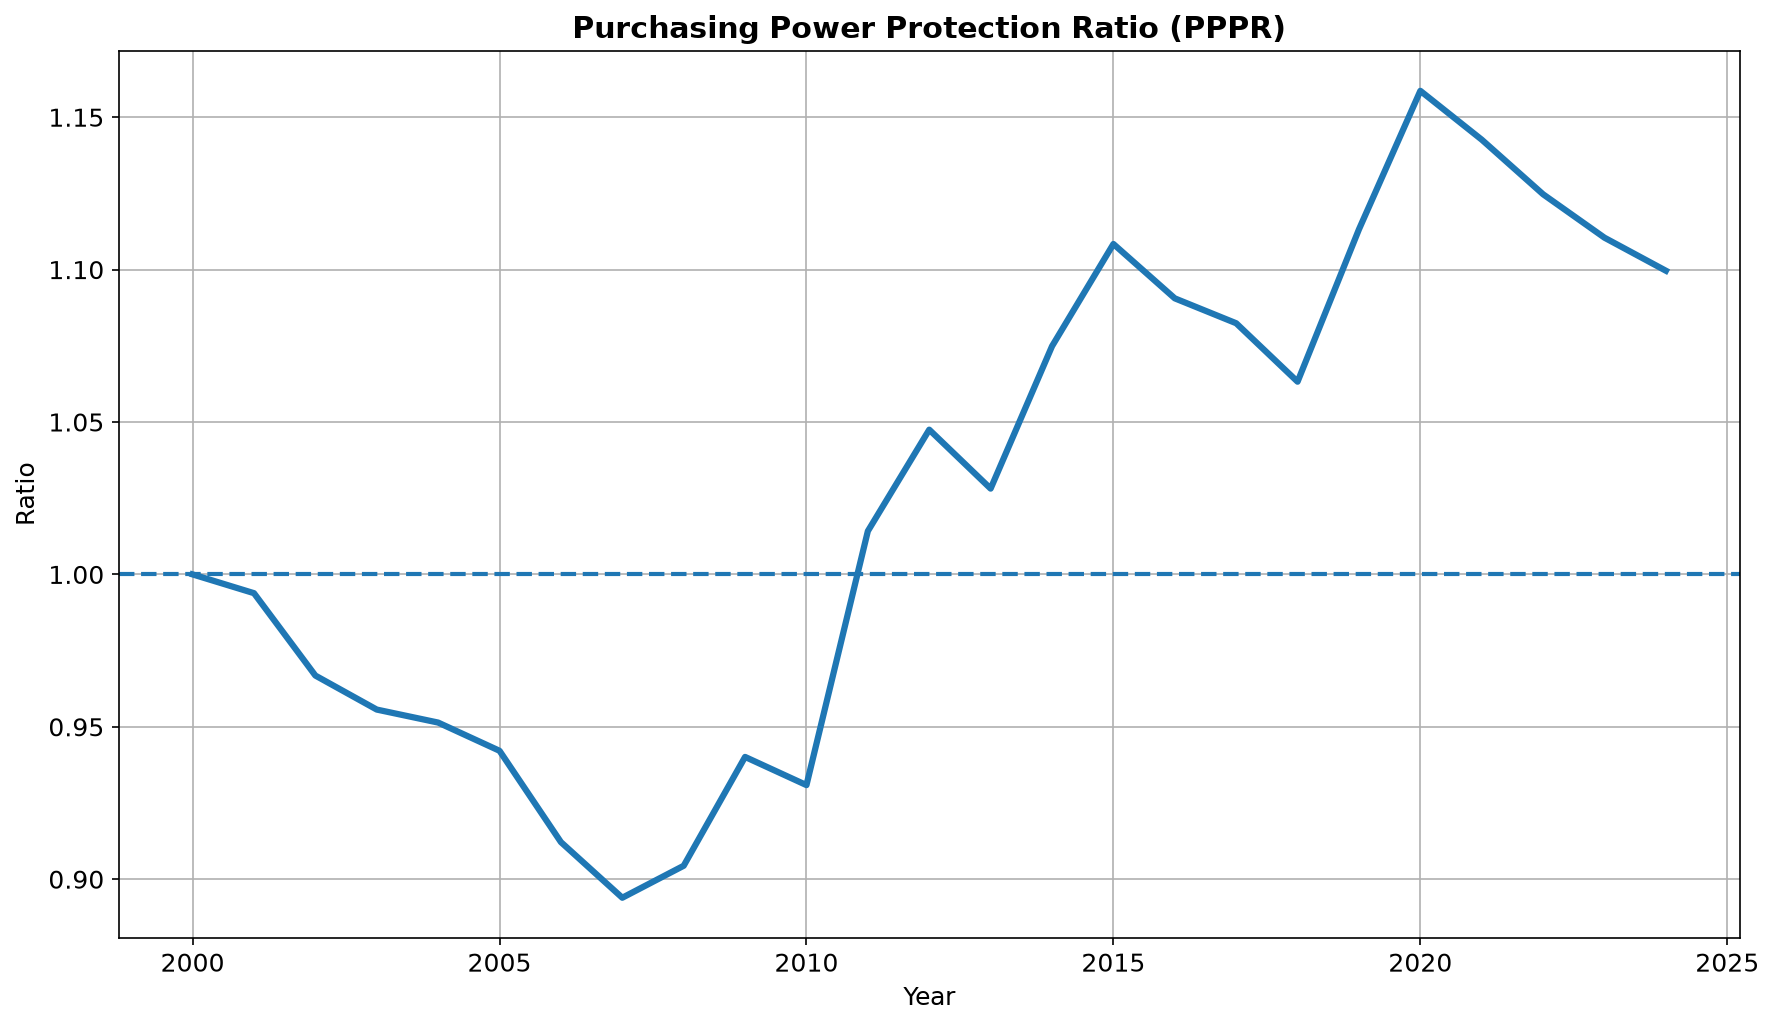

In [6]:
plt.figure()

plt.plot(
    df["year"],
    df["PPPR"],
    linewidth=3
)

plt.axhline(y=1, linestyle="--", linewidth=2)

plt.title("Purchasing Power Protection Ratio (PPPR)")
plt.xlabel("Year")
plt.ylabel("Ratio")

plt.tight_layout()

plt.savefig(
    FIGURES / "figure_04_pppr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Figure 5 — Inflation vs Nominal Wage Growth

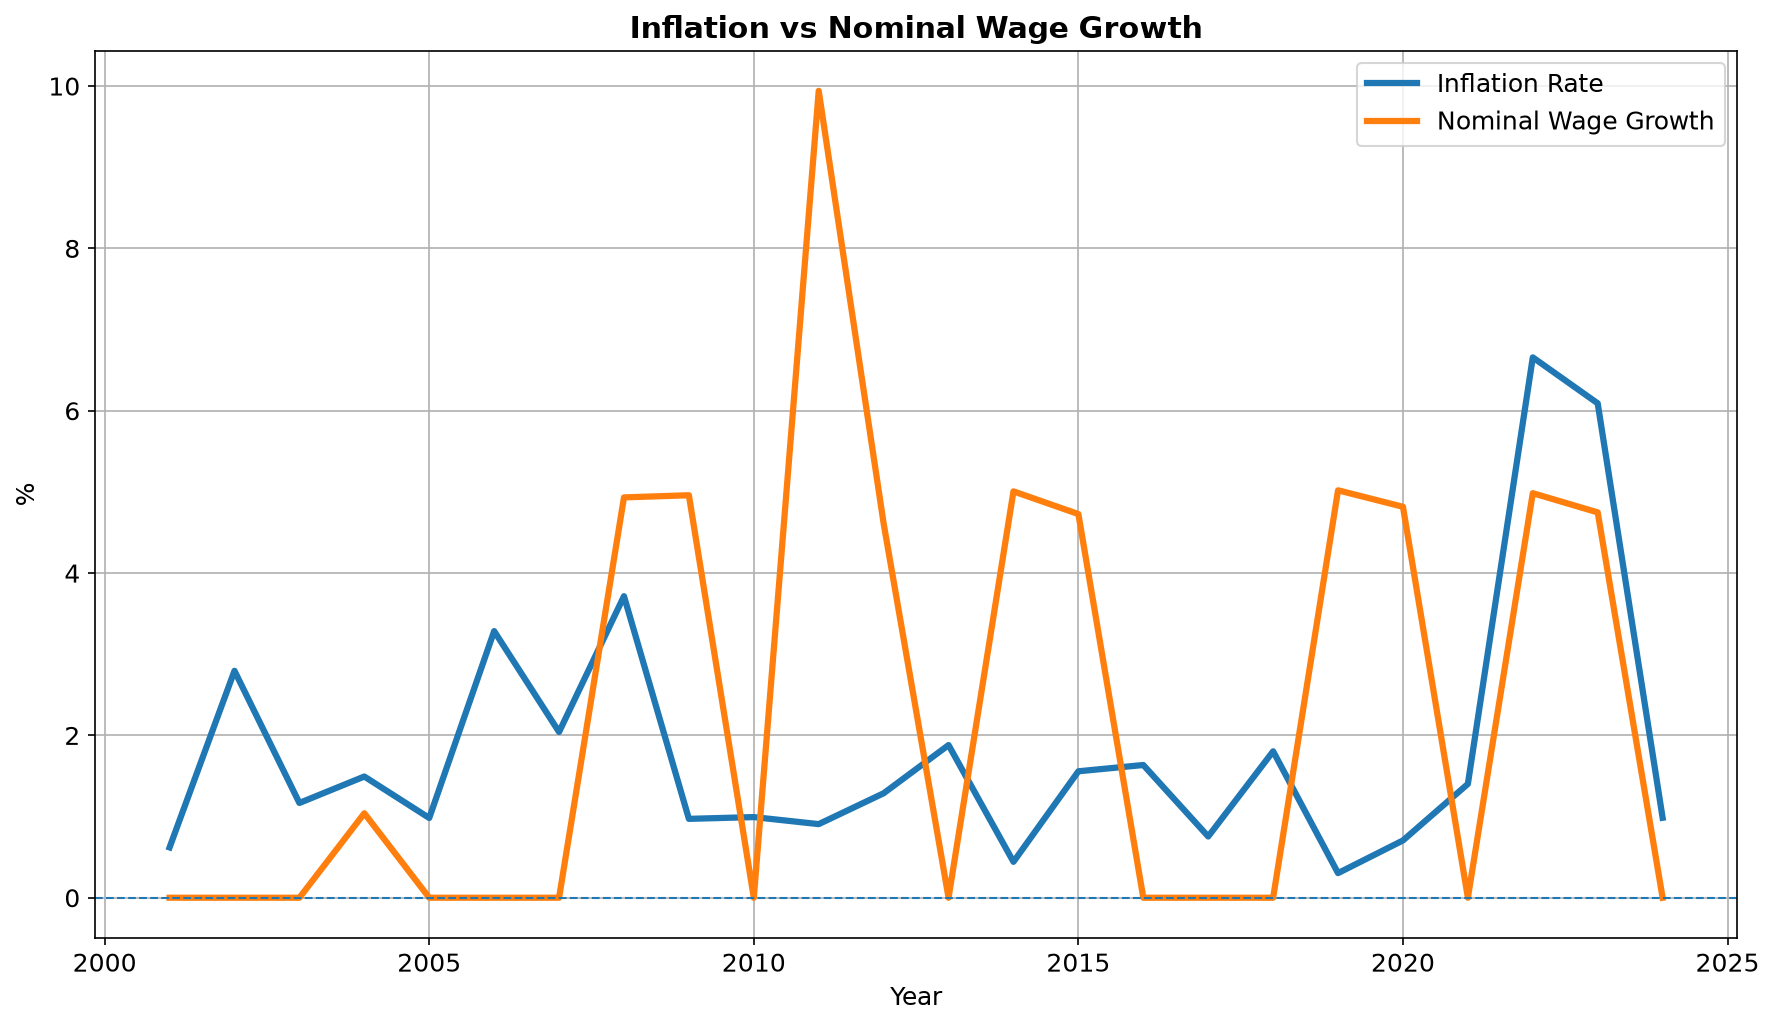

In [7]:
plt.figure()

plt.plot(
    df["year"],
    df["Inflation_Rate"],
    linewidth=3,
    label="Inflation Rate"
)

plt.plot(
    df["year"],
    df["Nominal_Wage_Growth"],
    linewidth=3,
    label="Nominal Wage Growth"
)

plt.axhline(y=0, linestyle="--", linewidth=1)

plt.title("Inflation vs Nominal Wage Growth")
plt.xlabel("Year")
plt.ylabel("%")

plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES / "figure_05_inflation_vs_wage_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Figure 6 — Cumulative Growth

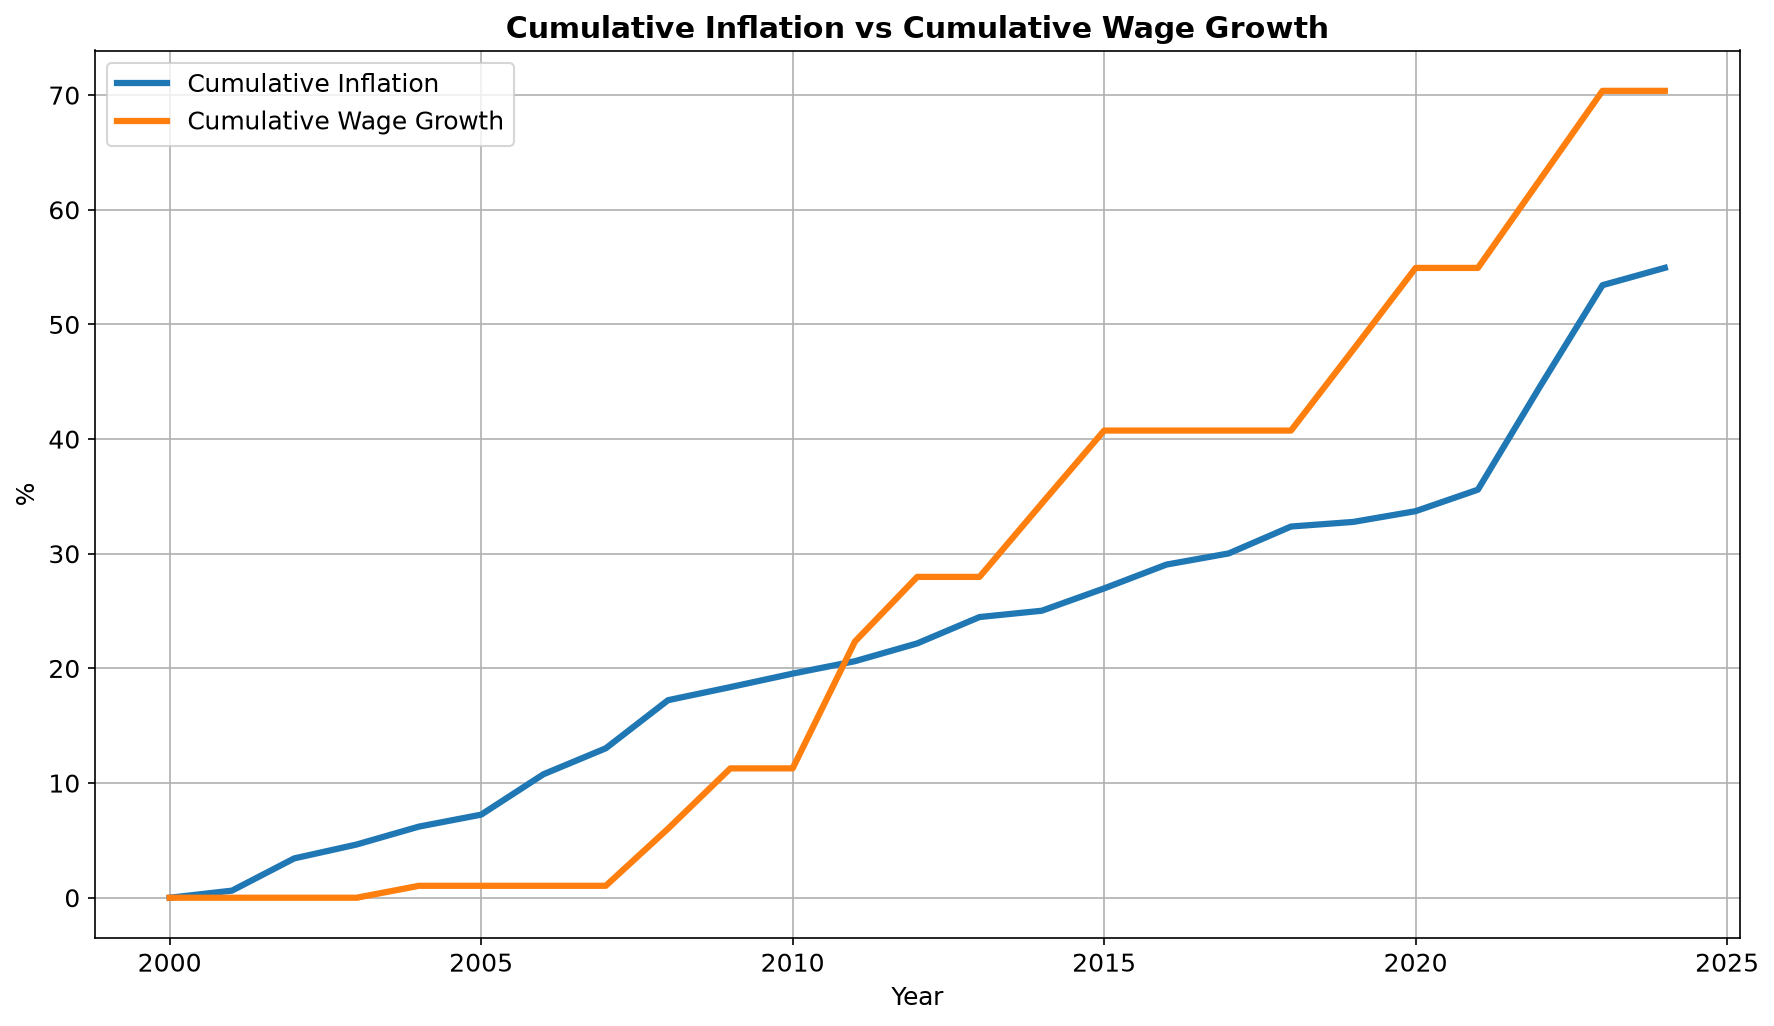

In [8]:
plt.figure()

plt.plot(
    df["year"],
    df["Cumulative_Inflation"],
    linewidth=3,
    label="Cumulative Inflation"
)

plt.plot(
    df["year"],
    df["Cumulative_Wage_Growth"],
    linewidth=3,
    label="Cumulative Wage Growth"
)

plt.title("Cumulative Inflation vs Cumulative Wage Growth")
plt.xlabel("Year")
plt.ylabel("%")

plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES / "figure_06_cumulative_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Figure 7 — Revaluation Timeline

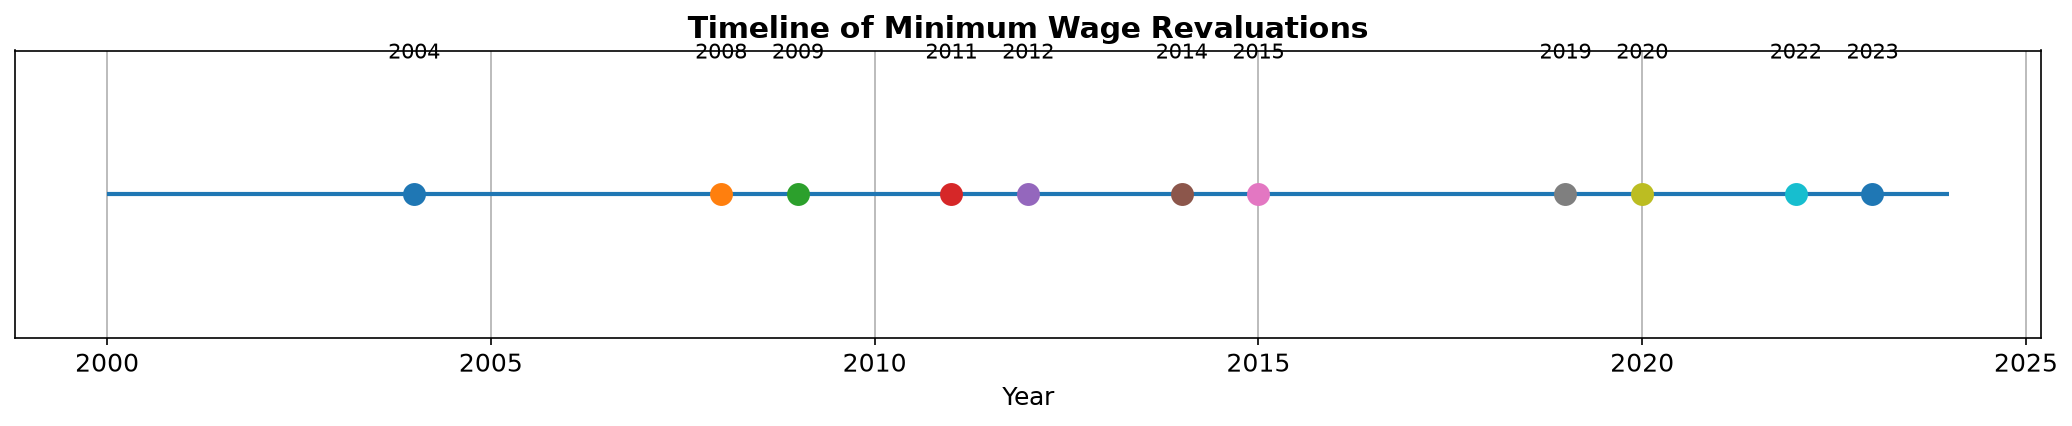

In [9]:
revaluation_years = df.loc[
    df["Nominal_Wage_Growth"].fillna(0) > 0,
    "year"
].tolist()

plt.figure(figsize=(14, 3))
plt.hlines(1, df["year"].min(), df["year"].max(), linewidth=2)

for year in revaluation_years:
    plt.plot(year, 1, marker="o", markersize=10)
    plt.text(year, 1.05, str(year), ha="center", va="bottom", fontsize=10)

plt.yticks([])
plt.title("Timeline of Minimum Wage Revaluations")
plt.xlabel("Year")

plt.tight_layout()

plt.savefig(
    FIGURES / "figure_07_revaluation_timeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Figure 8 — Economic Heatmap

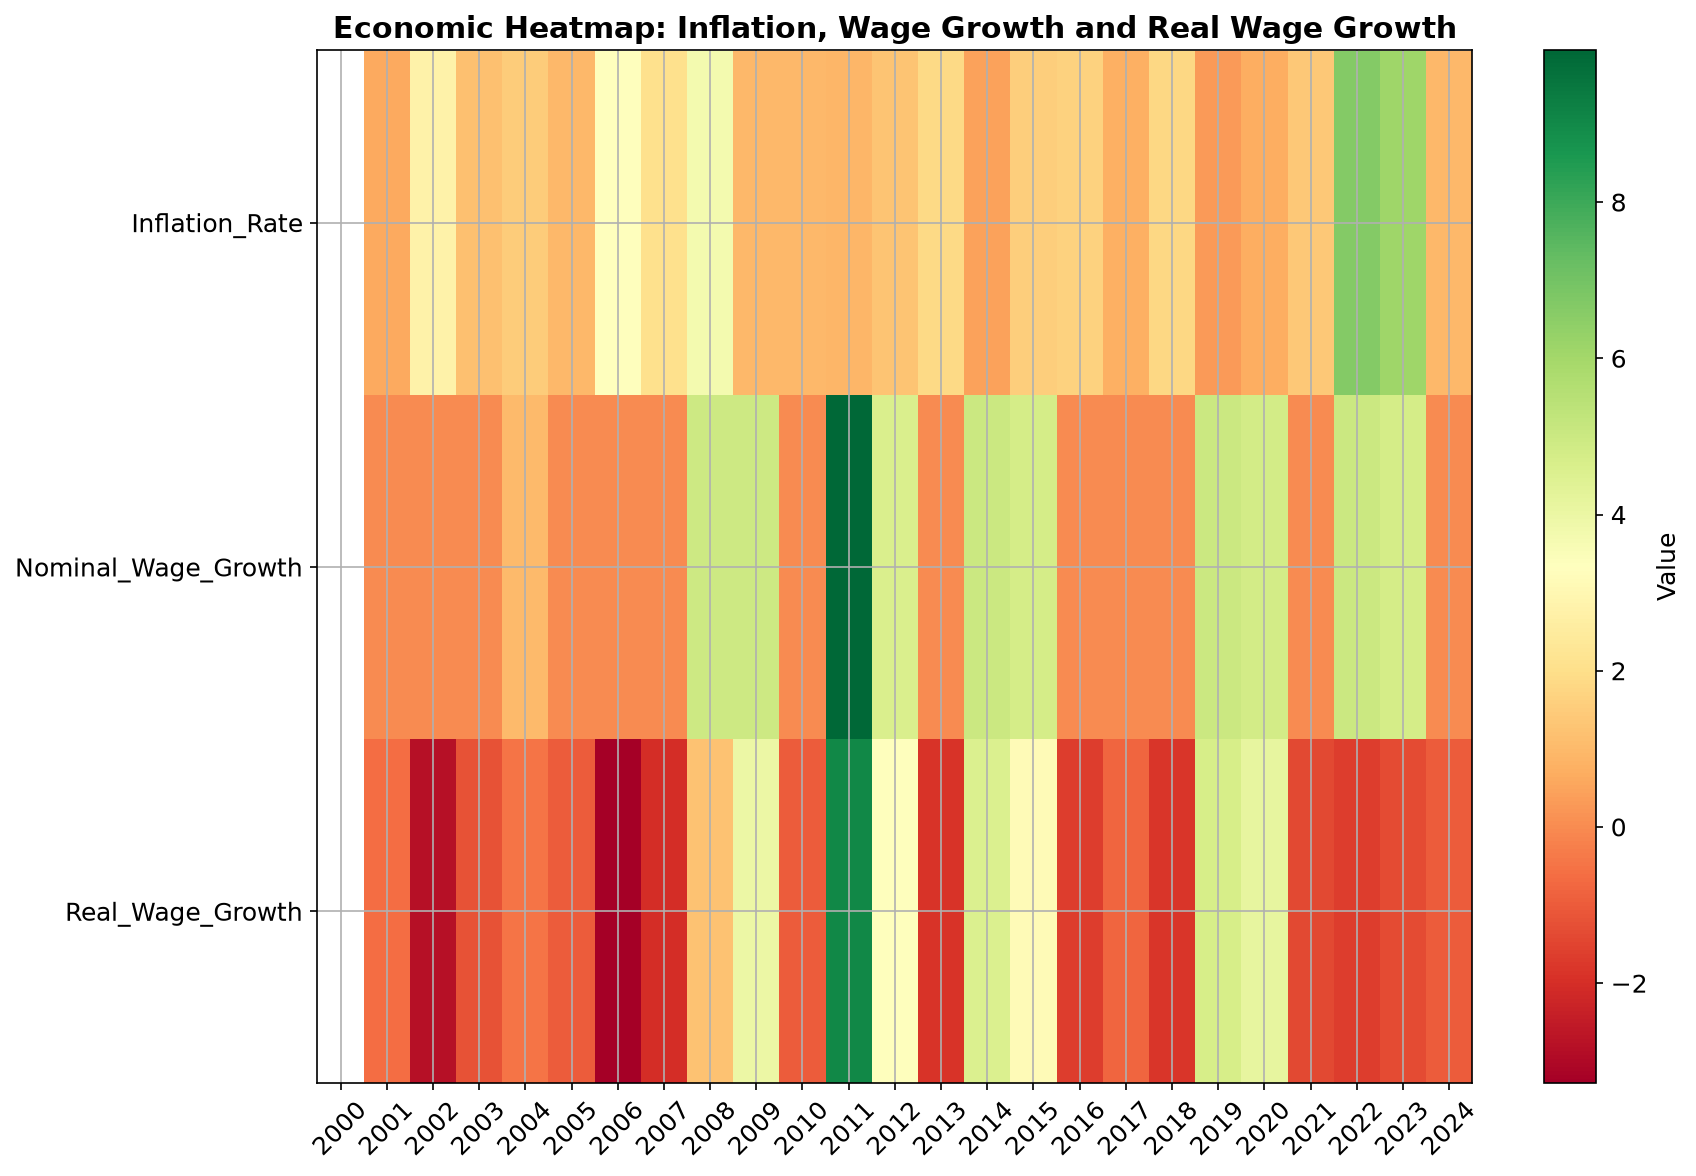

In [10]:
# Create a simple matrix for visual intensity
heat_df = df[[
    "year",
    "Inflation_Rate",
    "Nominal_Wage_Growth",
    "Real_Wage_Growth"
]].copy()

heat_df = heat_df.set_index("year")

plt.figure(figsize=(12, 8))
plt.imshow(heat_df.T, aspect="auto", cmap="RdYlGn", interpolation="nearest")

plt.colorbar(label="Value")

plt.yticks(
    range(len(heat_df.columns)),
    heat_df.columns
)

plt.xticks(
    range(len(heat_df.index)),
    heat_df.index,
    rotation=45
)

plt.title("Economic Heatmap: Inflation, Wage Growth and Real Wage Growth")
plt.tight_layout()

plt.savefig(
    FIGURES / "figure_08_economic_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Export Summary

In [11]:
print("=" * 70)
print("PUBLICATION FIGURES GENERATED")
print("=" * 70)
print()

for file in sorted(FIGURES.glob("*.png")):
    print(file.name)

print()
print("All publication figures successfully exported.")

PUBLICATION FIGURES GENERATED

figure_01_executive_dashboard.png
figure_01_smig_vs_cpi.png
figure_02_base100.png
figure_02_base100_comparison.png
figure_03_inflation.png
figure_03_purchasing_power_gap.png
figure_04_pppr.png
figure_04_wage_growth.png
figure_05_inflation_vs_wage_growth.png
figure_05_real_wage.png
figure_06_cumulative_growth.png
figure_06_gap.png
figure_07_pppr.png
figure_07_revaluation_timeline.png
figure_08_economic_heatmap.png

All publication figures successfully exported.
